# a. Kirkwood-Buff Theory and Diffusion Interaction Parameters (kD)
This notebook implements the mathematical equations for the diffusion interaction parameters in multicomponent solutions as presented in the publication:
**"Influence of Co-Solutes and Solvents on Diffusion Interaction Parameters in Multicomponent Solutions: New Insights through the Kirkwood−Buff Theory"** 
by Jiyoung Yang et al., *J. Phys. Chem. B* 2025, 129, 10381−10391 (DOI: 10.1021/acs.jpcb.5c03102).

In [8]:

import numpy as np
import sympy as sp
from sympy import symbols, init_printing, simplify, Eq
init_printing()

# Define symbols
rho1, rho2, rho3 = symbols('rho_1 rho_2 rho_3', positive=True, real=True)
G11, G12, G22, G13, G23, G33 = symbols('G_11 G_12 G_22 G_13 G_23 G_33', real=True)
eta0 = symbols('eta^0', positive=True, real=True)
T, R, V = symbols('T R V', positive=True, real=True)


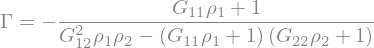

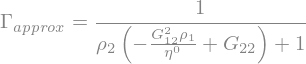

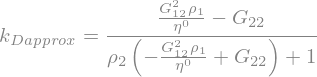

In [9]:

# 2.2. Diffusion Interaction Parameter in Binary Solutions

# Eq (18): Cofactors B^ij
B11 = rho2 + rho2**2 * G22
B12 = -rho1 * rho2 * G12
B21 = B12
B22 = rho1 + rho1**2 * G11

# Eq (19): Determinant |B|
detB = B22 * B11 - B12**2
detB_simplified = (rho1 + rho1**2 * G11) * (rho2 + rho2**2 * G22) - rho1**2 * rho2**2 * G12**2

# Eq (20): A22
A22 = (rho1 * (1 + rho1 * G11)) / detB_simplified

# Eq (21): Thermodynamic factor Gamma
Gamma_binary = rho2 * A22
Gamma_binary_simplified = simplify(Gamma_binary)
display(Eq(symbols('Gamma'), Gamma_binary_simplified))

# Eq (22): Simplified Gamma
Gamma_approx = 1 / (1 + rho2 * (G22 - (rho1 * G12**2 / eta0)))
display(Eq(symbols('Gamma_approx'), Gamma_approx))

# Eq (23): Simplified k_D
k_D_approx = ((rho1 * G12**2 / eta0) - G22) / (1 + rho2 * (G22 - (rho1 * G12**2 / eta0)))
display(Eq(symbols('k_D_approx'), k_D_approx))


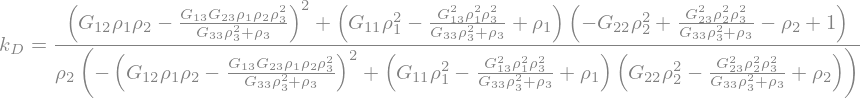

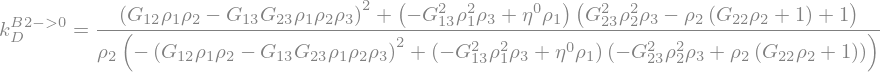

In [10]:

# 2.3. Diffusion Interaction Parameter in Ternary Solutions

# Eq (31-33): M matrix elements
M11 = rho1 + rho1**2 * G11 - (rho1 * rho3 * G13)**2 / (rho3 + rho3**2 * G33)
M22 = rho2 + rho2**2 * G22 - (rho2 * rho3 * G23)**2 / (rho3 + rho3**2 * G33)
M12 = rho1 * rho2 * G12 - (rho1 * rho3 * G13) * (rho2 * rho3 * G23) / (rho3 + rho3**2 * G33)

# Eq (35): Determinant |M|
detM = M11 * M22 - M12**2

# Eq (36): Derivative of chemical potential
dmu2_drho2 = R * T * (M11 / detM)

# Eq (37): Diffusion interaction parameter k_D
k_D_ternary = (1 / rho2) * (M11 * (1 - M22) + M12**2) / (M11 * M22 - M12**2)
display(Eq(symbols('k_D'), k_D_ternary))

# Eq (40-42): Approximations M_bar
M_bar_11 = rho1 * eta0 - (rho1 * rho3 * G13)**2 / rho3
M_bar_22 = rho2 * (1 + rho2 * G22) - (rho2 * rho3 * G23)**2 / rho3
M_bar_12 = rho1 * rho2 * G12 - (rho1 * rho3 * G13) * (rho2 * rho3 * G23) / rho3

# Eq (43): k_D for low cosolute concentrations
k_D_B2_0 = (1 / rho2) * (M_bar_11 * (1 - M_bar_22) + M_bar_12**2) / (M_bar_11 * M_bar_22 - M_bar_12**2)
display(Eq(symbols('k_D^{B2->0}'), k_D_B2_0))


In [11]:

# Numerical functions to evaluate the equations

def calculate_kD_binary(rho1, rho2, G11, G12, G22):
    '''Calculate k_D for a binary solution using the exact formula'''
    detB = (rho1 + rho1**2 * G11) * (rho2 + rho2**2 * G22) - rho1**2 * rho2**2 * G12**2
    Gamma = (rho2 * rho1 * (1 + rho1 * G11)) / detB
    k_D = (Gamma - 1) / rho2
    return k_D

def calculate_kD_binary_approx(rho1, rho2, G12, G22, eta0):
    '''Calculate k_D for a binary solution using the approximation (Eq 23)'''
    num = (rho1 * G12**2 / eta0) - G22
    den = 1 + rho2 * (G22 - (rho1 * G12**2 / eta0))
    return num / den

def calculate_kD_ternary(rho1, rho2, rho3, G11, G22, G33, G12, G13, G23):
    '''Calculate k_D for a ternary solution using the exact formula (Eq 37)'''
    M11 = rho1 + rho1**2 * G11 - (rho1 * rho3 * G13)**2 / (rho3 + rho3**2 * G33)
    M22 = rho2 + rho2**2 * G22 - (rho2 * rho3 * G23)**2 / (rho3 + rho3**2 * G33)
    M12 = rho1 * rho2 * G12 - (rho1 * rho3 * G13) * (rho2 * rho3 * G23) / (rho3 + rho3**2 * G33)
    
    num = M11 * (1 - M22) + M12**2
    den = M11 * M22 - M12**2
    return (1 / rho2) * (num / den)

def calculate_kD_ternary_approx(rho1, rho2, rho3, G12, G13, G22, G23, eta0):
    '''Calculate k_D for a ternary solution with low cosolute concentrations (Eq 43)'''
    M_bar_11 = rho1 * eta0 - (rho1 * rho3 * G13)**2 / rho3
    M_bar_22 = rho2 * (1 + rho2 * G22) - (rho2 * rho3 * G23)**2 / rho3
    M_bar_12 = rho1 * rho2 * G12 - (rho1 * rho3 * G13) * (rho2 * rho3 * G23) / rho3
    
    num = M_bar_11 * (1 - M_bar_22) + M_bar_12**2
    den = M_bar_11 * M_bar_22 - M_bar_12**2
    return (1 / rho2) * (num / den)


# 3. Geometrical Intuition: The Schur Complement (Shadow vs Slice)

In the mathematical derivation of the ternary diffusion interaction parameter, we constrain the co-solute density fluctuations to be zero ($d\rho_3 = 0$). This constraint forces the 3x3 fluctuation matrix $\mathbf{S}$ to collapse into a 2x2 matrix $\mathbf{M}$ via the **Schur complement**:
$$ \mathbf{M} = \mathbf{S}_{aa} - \mathbf{S}_{ab} \mathbf{S}_{bb}^{-1} \mathbf{S}_{ba} $$

To intuitively understand this, we can visualize the fluctuations as a cloud of points in 3D space.
1. **The Shadow ($\mathbf{S}_{aa}$)**: If we simply ignore the co-solute's 3rd dimension and project all 3D points down onto the 2D plane (marginalization), we get the direct binary interactions.
2. **The Slice ($\mathbf{M}$)**: By setting $d\rho_3 = 0$, we are mathematically taking a **slice (cross-section)** of the 3D fluctuation cloud exactly along the 2D plane.

The term $\mathbf{S}_{ab} \mathbf{S}_{bb}^{-1} \mathbf{S}_{ba}$ represents the geometric difference between the Shadow (projection) and the Slice (intersection).

### Preferential Binding vs Exclusion
Depending on how the co-solute interacts with the protein ($G_{23}$) and water ($G_{13}$), the 3D fluctuation cloud will tilt differently.
- **Preferential Binding (e.g., Urea)**: The co-solute binds to the protein. The 3D cloud tilts such that slicing it at $d\rho_3=0$ creates a strongly squeezed 2D cross-section.
- **Preferential Exclusion (e.g., Glycerol)**: The co-solute is excluded from the protein. The cloud tilts in a different direction, yielding a different slice geometry.

Below, we simulate 300,000 points of density fluctuations in 3D space and visualize how taking the "Slice" (Schur complement) restricts the fluctuations compared to the "Shadow".
> **Note on Matrix Construction & Sign Logic**:
> The 3D fluctuation covariance matrices ({	ext{bind}}$ and {	ext{excl}}$) are hypothetical conceptual matrices constructed based on physical Kirkwood-Buff principles ({ij} = 
ho_i \delta_{ij} + 
ho_i 
ho_j G_{ij}$):
> * **Diagonal Elements ({11}=10.0, S_{22}=2.0, S_{33}=5.0$)**: Must be strictly positive ($>0$) to ensure positive variance of individual component densities.
> * **Solvent-Protein Cross-Term ({12} = -1.0 < 0$)**: Negative due to volume exclusion (increasing protein density displaces solvent molecules).
> * **Scenario A (Preferential Binding, e.g., Urea/Arginine)**: Set **{23} = +2.5 > 0*. Positive cross-correlation reflects strong co-solute attraction to the protein ({23} > 0$), meaning co-solute density increases alongside protein density ($\Delta
ho_2 > 0 \implies \Delta
ho_3 > 0$), tilting the 3D fluctuation cloud diagonally upward.
> * **Scenario B (Preferential Exclusion, e.g., Glycerol/Sugars)**: Set **{23} = -2.5 < 0*. Negative cross-correlation reflects co-solute repulsion from the protein surface ({23} < 0$), meaning co-solute density locally decreases as protein density increases ($\Delta
ho_2 > 0 \implies \Delta
ho_3 < 0$), while solvent-co-solute correlation increases ({13} = +2.0 > 0$, preferential hydration).



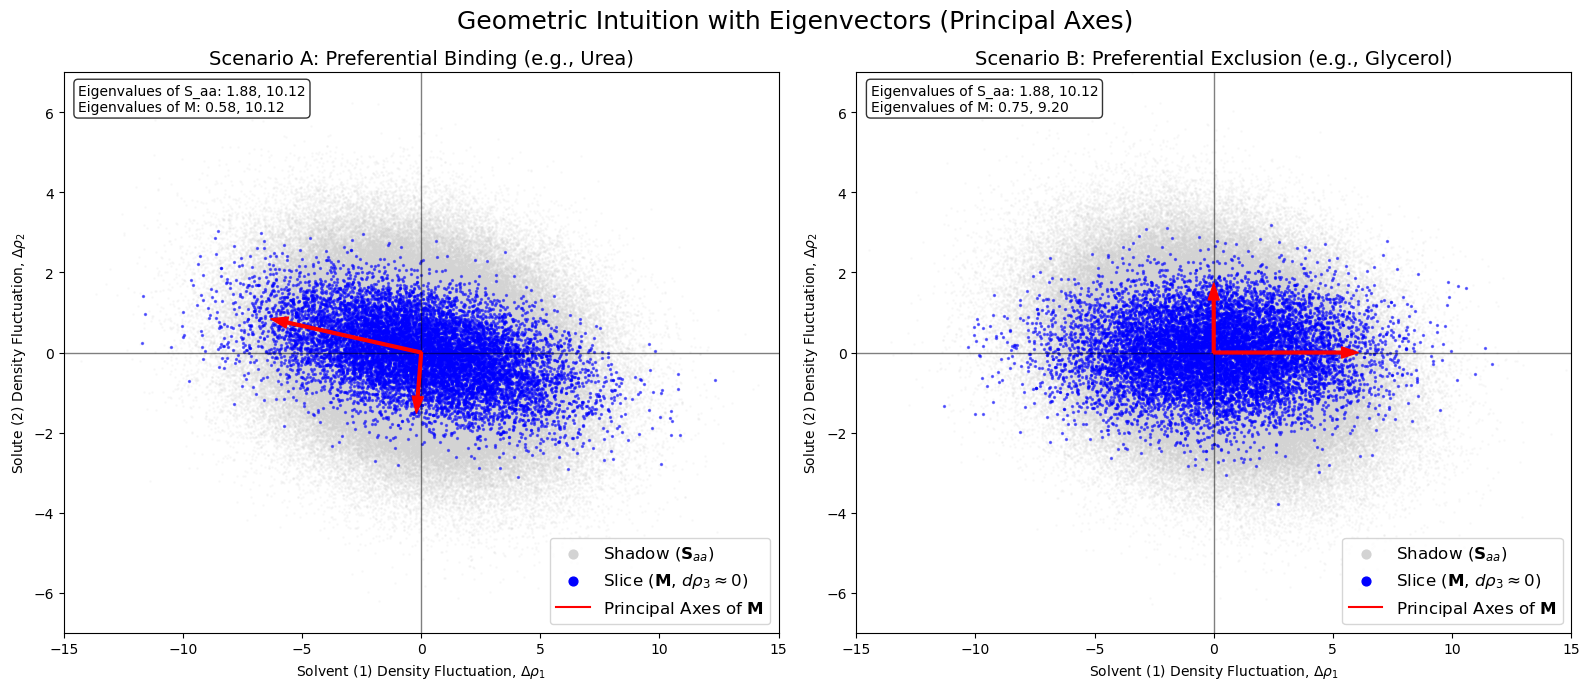

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Scenario A: Preferential Binding (Strong Protein-Co-solute attraction)
S_bind = np.array([
    [10.0, -1.0,  0.5],
    [-1.0,  2.0,  2.5],
    [ 0.5,  2.5,  5.0]
])

# Scenario B: Preferential Exclusion (Protein repels Co-solute)
S_excl = np.array([
    [10.0, -1.0,  2.0],
    [-1.0,  2.0, -2.5],
    [ 2.0, -2.5,  5.0]
])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def plot_scatter_slice(ax, S, title):
    np.random.seed(42)
    n_samples = 300000
    mean = np.array([0, 0, 0])
    points = np.random.multivariate_normal(mean, S, n_samples)
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    
    # 1. Shadow (S_aa)
    S_aa = S[:2, :2]
    ax.scatter(x, y, s=1, color='lightgray', alpha=0.1, label=r'Shadow ($\mathbf{S}_{aa}$)')
    
    # Eigen decomposition for S_aa
    eigvals_aa, eigvecs_aa = np.linalg.eigh(S_aa)
    
    # 2. Slice (M)
    tolerance = 0.1
    mask = np.abs(z) < tolerance
    ax.scatter(x[mask], y[mask], s=2, color='blue', alpha=0.5, label=r'Slice ($\mathbf{M}$, $d\rho_3 \approx 0$)')
    
    # Calculate M analytically for eigenvalues
    S_ab = S[:2, 2].reshape(2, 1)
    S_bb = S[2, 2]
    M = S_aa - (S_ab @ S_ab.T) / S_bb
    
    # Eigen decomposition for M
    eigvals_M, eigvecs_M = np.linalg.eigh(M)
    
    # Plot Eigenvectors for M (Principal axes of the slice)
    for i in range(2):
        # Scale eigenvector by square root of eigenvalue (standard deviation)
        vec_M = eigvecs_M[:, i] * np.sqrt(eigvals_M[i]) * 2 # 2-sigma length
        ax.annotate('', xy=vec_M, xytext=(0, 0),
                    arrowprops=dict(facecolor='red', edgecolor='red', width=2, headwidth=8),
                    zorder=5)
        if i == 0:
            ax.plot([], [], color='red', label='Principal Axes of $\mathbf{M}$')
            
    # Print Eigenvalues
    ax.text(0.02, 0.98, f"Eigenvalues of S_aa: {eigvals_aa[0]:.2f}, {eigvals_aa[1]:.2f}\nEigenvalues of M: {eigvals_M[0]:.2f}, {eigvals_M[1]:.2f}",
            transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r"Solvent (1) Density Fluctuation, $\Delta\rho_1$")
    ax.set_ylabel(r"Solute (2) Density Fluctuation, $\Delta\rho_2$")
    ax.axhline(0, color='black', lw=1, alpha=0.5)
    ax.axvline(0, color='black', lw=1, alpha=0.5)
    
    ax.set_xlim(-15, 15)
    ax.set_ylim(-7, 7)
    
    leg = ax.legend(loc='lower right', fontsize=12)
    for lh in leg.legend_handles: 
        if hasattr(lh, 'set_alpha'):
            lh.set_alpha(1)
        if hasattr(lh, '_sizes'):
            lh._sizes = [40]

plot_scatter_slice(axes[0], S_bind, "Scenario A: Preferential Binding (e.g., Urea)")
plot_scatter_slice(axes[1], S_excl, "Scenario B: Preferential Exclusion (e.g., Glycerol)")

plt.suptitle("Geometric Intuition with Eigenvectors (Principal Axes)", fontsize=18)
plt.tight_layout()
plt.show()


## 3D Visualization of the Schur Complement Slice ($d\rho_3 = 0$)
To make the concept of the "Slice" (Schur complement) more intuitive, we visualize the full 3-dimensional fluctuation space ($\Delta\rho_1, \Delta\rho_2, \Delta\rho_3$). 

- The **gray cloud** represents all possible thermodynamic fluctuations in 3D.
- The **green plane** represents the constraint $d\rho_3 = 0$ (constant co-solute chemical potential).
- The **red dots** are the "Slice": the specific thermodynamic states that satisfy this constraint. Projecting these red dots down to the 2D plane gives us the Schur complement ellipse!
\n

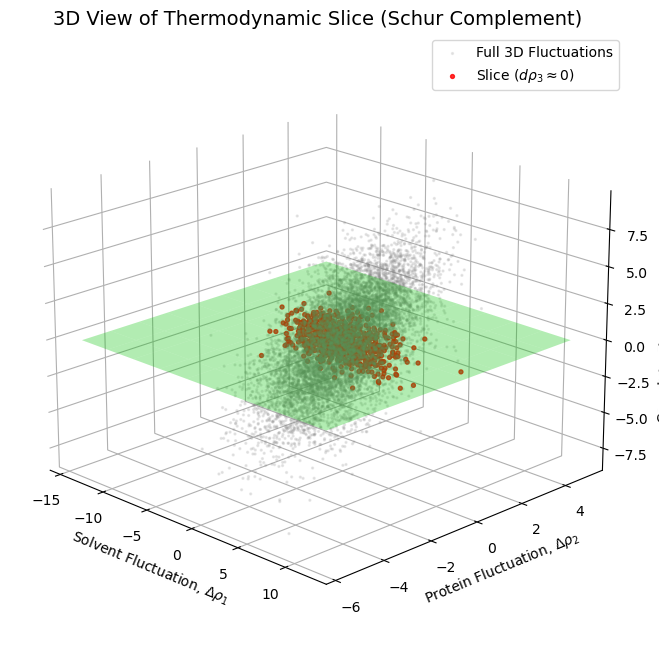

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Use the Binding Scenario Matrix from the previous cell
S_3d = np.array([
    [10.0, -1.0, 0.5],
    [-1.0,  2.0, 2.5],
    [0.5,   2.5, 5.0]
])

# Sample 3D points
np.random.seed(42)
points_3d = np.random.multivariate_normal([0, 0, 0], S_3d, 10000)
x, y, z = points_3d[:, 0], points_3d[:, 1], points_3d[:, 2]

# Set white background for the figure
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
# Set white background for the 3D axes
ax.set_facecolor('white')
# Also make the panes white to ensure clean background
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# 1. Plot the full 3D shadow (Gray) - Increased alpha and size for visibility
ax.scatter(x, y, z, c='gray', alpha=0.15, s=2, label="Full 3D Fluctuations")

# 2. Draw the Slice Plane (z = 0) - Dynamically cover the entire range of points
x_min, x_max = np.min(x), np.max(x)
y_min, y_max = np.min(y), np.max(y)
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(y_min, y_max, 10))
zz = np.zeros_like(xx)
ax.plot_surface(xx, yy, zz, color='lime', alpha=0.3)

# 3. Highlight the Slice points (Red)
slice_tolerance = 0.2
slice_mask = np.abs(z) < slice_tolerance
ax.scatter(x[slice_mask], y[slice_mask], z[slice_mask], 
           c='red', alpha=0.8, s=8, label=rf"Slice ($d\rho_3 \approx 0$)")

ax.set_title("3D View of Thermodynamic Slice (Schur Complement)", fontsize=14)
ax.set_xlabel(rf"Solvent Fluctuation, $\Delta \rho_1$")
ax.set_ylabel(rf"Protein Fluctuation, $\Delta \rho_2$")
ax.set_zlabel(rf"Co-solute Fluctuation, $\Delta \rho_3$")

# Set view angle for better intuition
ax.view_init(elev=20, azim=-45)
ax.legend()
plt.show()


# 4. Package Integration: Verification with  API
Below we demonstrate how the  Python package provides streamlined classes (, , ) to compute exact Kirkwood-Buff diffusion interaction parameters ($) and analyze density fluctuation geometry.

In [14]:
import numpy as np
from kb_fluct import FluctuationMatrix, EllipseAnalyzer, TernarySystem

# System densities
rho1, rho2, rho3 = 33.3, 1.5, 0.5
G11, G22, G33 = -0.02, 0.50, 0.10
G12, G13, G23 = -0.10, 0.05, 0.25

# 1. TernarySystem kD Exact Calculation
ternary_sys = TernarySystem(rho1, rho2, rho3, G11, G22, G33, G12, G13, G23)
kD_exact = ternary_sys.calculate_kD_exact()
print(f"Ternary kD (Exact): {kD_exact:.4f}")

# 2. Binary Fluctuation Matrix & Ellipse Geometry
fluct = FluctuationMatrix(rho1, rho2).fit(G11, G22, G12)
ellipse = EllipseAnalyzer().fit(fluct.S_matrix_)

print("Fluctuation Matrix S:")
print(np.round(fluct.S_matrix_, 4))
print(f"Tilt Angle: {ellipse.tilt_angle_degrees_:.2f} deg")
print(f"Eccentricity: {ellipse.eccentricity_:.4f}")


Ternary kD (Exact): -2.8935
Fluctuation Matrix S:
[[11.1222 -4.995 ]
 [-4.995   2.625 ]]
Tilt Angle: 155.19 deg
Eccentricity: 0.9882
